# <h1 style="text-align: center;">Optimal Control of TCLab using a Gaussian process regression embedded in Pyomo - notebook v6 with v5c2</h1>

<p style="text-align: center;">Alex Dowling<sup>a</sup>, Jacob P. Krell<sup>b</sup>, David S. Mebane<sup>b</sup>

<p style="text-align: center;"><sup>a</sup>Department of Chemical and Biomolecular Engineering, University of Notre Dame, Notre Dame, IN 46556, USA <br>
<sup>b</sup>Department of Mechanical and Aerospace Engineering, West Virginia University, Morgantown, WV, 26506-6106, USA</p>

## Change Log
- This files is derived from `pyomo_tclab_v5c2.ipynb`
- First implementation of optimization (derived from `pyomo_tclab_v6_optimize1.ipynb`) in Pyomo

## Setup

In [1]:
import os
dir = os.path.abspath('')  # directory of notebook
import pandas as pd
import numpy as np
from FoKL import FoKLRoutines
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

Load and parse data:

In [2]:
data = pd.read_csv(os.path.join(dir, "tclab_sine_test.csv"))

tvec = data["Time"].values
Q1 = data["Q1"].values
TS1 = data["T1"].values

Define heater power control signal:

In [3]:
Q1f = interp1d(tvec, Q1, kind='previous')  # piecewise Q1
dQ1f_analytic = lambda t: 1500 * np.cos(30 * np.pi * t / tvec[-1]) * np.pi / tvec[-1]  # derivative of analytic Q1
dQ1f = interp1d(tvec, dQ1f_analytic(tvec), kind='previous')  # piecewise derivative of analytic Q1

## Derivative of Smoothed Data

Since raw measurements are noisy, a smoothing functions is applied before calculating the time derivative.

### Smoothing

Using a rolling average as the smoothing function,

In [4]:
window = 9  # odd number, mean at center +/- floor(window/2))

In [5]:
def smooth(TS1, window):
    """Apply centered average of size window."""
    TS1_smooth = np.zeros_like(TS1)
    w2 = int(np.floor(window / 2))
    w2p1 = w2 + 1

    # bleed in:
    for i in range(w2):
        TS1_smooth[i] = np.mean(TS1[:(i + w2p1)])

    # center:
    for i in range(w2, TS1_smooth.size - w2):
        TS1_smooth[i] = np.mean(TS1[(i - w2):(i + w2p1)])

    # bleed out:
    for i in range(-w2, 0):
        TS1_smooth[i] = np.mean(TS1[(i - w2)::])

    return TS1_smooth

TS1_smooth = smooth(TS1, window)

### Derivative

In [6]:
def gradient_h4(x, h):
    """h is step size. Order of error is h^4."""
    dx = np.zeros_like(x)

    # bleed in:
    h2 = 2 * h
    dx[0] = (x[1] - x[0]) / h
    dx[1] = (x[2] - x[0]) / h2

    # center difference:
    h12 = 12 * h
    for i in range(2, x.shape[0] - 2):
        dx[i] = (x[i - 2] - 8 * x[i - 1] + 8 * x[i + 1] - x[i + 2]) / h12
    
    # bleed out:
    dx[-2] = (x[-1] - x[-3]) / h2
    dx[-1] = (x[-1] - x[-2]) / h

    return dx

dTS1 = gradient_h4(TS1_smooth, tvec[1] - tvec[0])
dTS1f = interp1d(tvec, dTS1, kind='previous')  # piecewise, grab previous value

## GP Model of Derivative

In [7]:
GP_dT = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True)
_ = GP_dT.fit([TS1_smooth, Q1, dQ1f(tvec)], dTS1, clean=True)

[1, -5046.695533701695]
[2, -5043.638666735433]
[2, -5080.513958480084]
[3, -5105.375847137966]
[3, -5122.547074440649]
[4, -5127.097247677269]
[4, -5133.585357226751]
[4, -5131.900419666858]
[5, -5143.058034467218]
[5, -5141.914061315322]
[5, -5139.984695019455]
[6, -5142.524894678475]


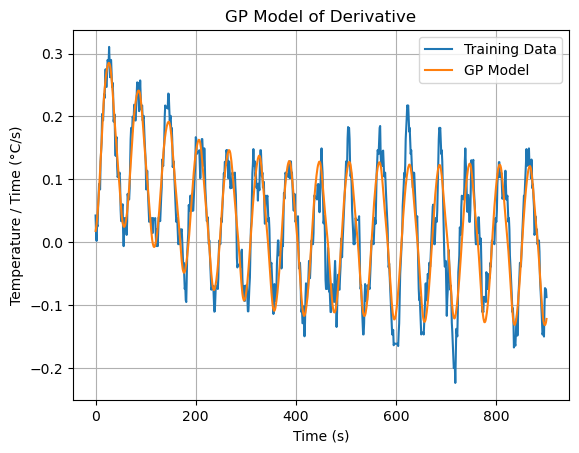

In [8]:
dTS1_GP = GP_dT.evaluate()

%matplotlib inline
plt.figure()
plt.plot(tvec, dTS1)
plt.plot(tvec, dTS1_GP)
plt.title("GP Model of Derivative")
plt.xlabel('Time (s)')
plt.ylabel('Temperature / Time (°C/s)')
plt.legend(['Training Data', 'GP Model'])
plt.grid()

## Application of Validated Dynamics $\dot{T} = f(T, Q, \dot{Q})$ to Step Test

### Setup

In [10]:
data_test = pd.read_csv(os.path.join(dir, "tclab_step_test.csv"))

tvec_test = data_test["Time"].values
TS1_test = data_test["T1"].values

### Smoothed Data

In [11]:
TS1_test_smooth = smooth(TS1_test, window)

dTS1_test = gradient_h4(TS1_test_smooth, tvec_test[1] - tvec_test[0])
dTS1f_test = interp1d(tvec_test, dTS1_test, kind='previous')  # piecewise, grab previous value

## Controller Reference Trajectory

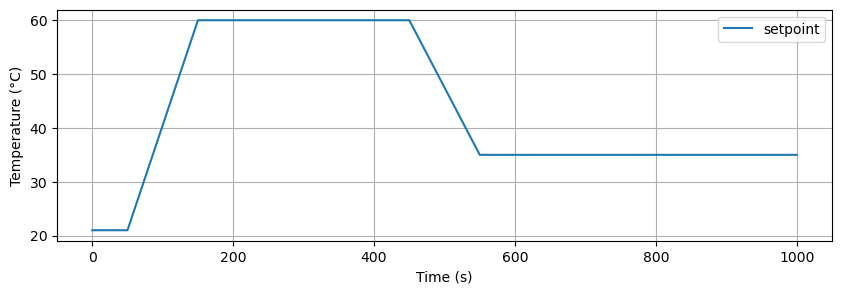

In [14]:
# time grid
tf = 1000
dt = 2
n = round(tf / dt)
t_grid = np.linspace(0, 1000, n + 1)

# ambient temperature
Tamb = 21

# setpoint/reference
def r(t):
    return np.interp(t, [0, 50, 150, 450, 550], [Tamb, Tamb, 60, 60, 35])

# plot the setpoint function
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(t_grid, r(t_grid), label="setpoint")
ax.set_ylabel('Temperature (°C)')
ax.set_xlabel("Time (s)")
ax.legend()
ax.grid(True)

## Optimization using GP Model

Reference for optimization of benchmark model: https://dowlinglab.github.io/pyomo-doe/notebooks/pyomo_simulation.html#controlling-to-a-reference-tractory

In [17]:
import pyomo.environ as pyo
import pyomo.dae as dae
from FoKL.fokl_to_pyomo import fokl_to_pyomo

In [18]:
# Create a Pyomo model
m = pyo.ConcreteModel('TCLab Heater with GP Model')

### Hard-coded develoopment of ```fokl_to_pyomo``` function, with continuous index ```t``` for ODE

Setup

In [26]:
# Function inputs:
xvars = ['Ts1', 'u1', 'du1']
yvars = 'dTs1'
draws = 5
t_span = [0, tf]

v3.3.0 ```fokl_to_pyomo```

In [23]:
fokl_to_pyomo(GP_dT, xvars, yvars, m, draws=draws)

# == GP_dT.to_pyomo(xvars, yvars, m, draws=draws)

Hard-coded additions:

In [28]:
# Define time domain
m.t = dae.ContinuousSet(bounds=(t_span[0], t_span[1]))

for var in xvars + [yvars]:
    m.add_component(f"{var}_t", pyo.Var(m.t))  # non-t vars indexed over t

'pyomo.dae.contset.ContinuousSet'>) on block TCLab Heater with GP Model with a
new Component (type=<class 'pyomo.dae.contset.ContinuousSet'>). This is
usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().


---

# Test dev

In [ ]:
path.append(os.path.join(dir, '..', '..', 'src'))
from FoKL.fokl_to_pyomo__test_dev_for_ODE_t import fokl_to_pyomo as fokl_to_pyomo_ODE

In [ ]:
m_ODE = pyo.ConcreteModel('TCLab Heater with GP Model')  # test pyomo model

fokl_to_pyomo_ODE(GP_dT, xvars, yvars, m_ODE, draws=draws, t_span=t_span)